### Regression of Student Error in Learning objectives onto Student Error in Identified Categories of Questions 

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
load_dotenv()

True

In [14]:
error_rate=pd.read_csv(os.getenv("error_per_kc"))
responses=pd.read_csv(os.getenv("RESPONSES_PROCESSED_PATH"))
level_1=pd.read_csv(os.getenv("level_1"))
level_2=pd.read_csv(os.getenv("level_2"))
level_3=pd.read_csv(os.getenv("level_3"))


In [15]:
# Extract question IDs from each level dataframe
level_1_qs = set(level_1['questions'].tolist())
level_2_qs = set(level_2['questions'].tolist())
level_3_qs = set(level_3['questions'].tolist())

def get_level_error(df,question_list):
    df=df[df['questions'].isin(question_list)]
    df['error']=1-df['responses']
    level_error_per_kc=(df.groupby(['uid','concepts']).agg(
        error=('error','mean'),
        solved=('responses','count')
).reset_index()
)
    return level_error_per_kc

level_1_error=get_level_error(responses,level_1_qs)
level_2_error=get_level_error(responses,level_2_qs)
level_3_error=get_level_error(responses,level_3_qs)

# Merge level errors with overall error rates
merged_1 = level_1_error.merge(error_rate, on=['uid', 'concepts'], suffixes=('_level1', '_overall'))
merged_2 = level_2_error.merge(error_rate, on=['uid', 'concepts'], suffixes=('_level2', '_overall'))
merged_3 = level_3_error.merge(error_rate, on=['uid', 'concepts'], suffixes=('_level3', '_overall'))

# Calculate correlations
corr_1 = merged_1['error_level1'].corr(merged_1['error_overall'])
corr_2 = merged_2['error_level2'].corr(merged_2['error_overall'])
corr_3 = merged_3['error_level3'].corr(merged_3['error_overall'])

print(f"Level 1 correlation: {corr_1:.4f}")
print(f"Level 2 correlation: {corr_2:.4f}")
print(f"Level 3 correlation: {corr_3:.4f}")

C:\Users\Hatem\AppData\Local\Temp\ipykernel_29496\2466722601.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error']=1-df['responses']
C:\Users\Hatem\AppData\Local\Temp\ipykernel_29496\2466722601.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error']=1-df['responses']
C:\Users\Hatem\AppData\Local\Temp\ipykernel_29496\2466722601.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

Level 1 correlation: 0.6505
Level 2 correlation: 0.9835
Level 3 correlation: 0.7333


In [26]:
def get_level_error_chronological(df, question_list, all_responses):
    """
    Compute early error on level questions (from question_list) in first half,
    and late error on ALL questions in second half.
    
    Returns:
    - early: error rate on level questions in first half
    - late: error rate on ALL questions in second half
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    all_responses = all_responses.copy()
    
    # Add sequence position for ALL responses (not just filtered ones)
    all_responses['seq_pos'] = all_responses.groupby('uid').cumcount() + 1
    
    # Get total responses per student
    total_responses = all_responses.groupby('uid')['seq_pos'].max().reset_index()
    total_responses.columns = ['uid', 'total_responses']
    
    # Determine half for each response in ALL responses
    all_responses = all_responses.merge(total_responses, on='uid')
    all_responses['half'] = all_responses['seq_pos'] <= (all_responses['total_responses'] / 2)
    all_responses['half_label'] = all_responses['half'].map({True: 'early', False: 'late'})
    
    # ---- EARLY: Level questions in first half ----
    # Filter to level questions
    early_df = all_responses[
        (all_responses['questions'].isin(question_list)) & 
        (all_responses['half_label'] == 'early')
    ].copy()
    early_df['error'] = 1 - early_df['responses']
    
    early_error = early_df.groupby(['uid', 'concepts']).agg(
        error_early=('error', 'mean'),
        solved_early=('responses', 'count')
    ).reset_index()
    
    # ---- LATE: ALL questions in second half ----
    late_df = all_responses[all_responses['half_label'] == 'late'].copy()
    late_df['error'] = 1 - late_df['responses']
    
    late_error = late_df.groupby(['uid', 'concepts']).agg(
        error_late=('error', 'mean'),
        solved_late=('responses', 'count')
    ).reset_index()
    
    return early_error, late_error

# Usage
level_1_early, level_1_late = get_level_error_chronological(
    responses, level_1_qs, responses
)
level_2_early, level_2_late = get_level_error_chronological(
    responses, level_2_qs, responses
)
level_3_early, level_3_late = get_level_error_chronological(
    responses, level_3_qs, responses
)

# Check sizes
print("Level 1 Early:", level_1_early.shape, "Late:", level_1_late.shape)
print("Level 2 Early:", level_2_early.shape, "Late:", level_2_late.shape)
print("Level 3 Early:", level_3_early.shape, "Late:", level_3_late.shape)

Level 1 Early: (191427, 4) Late: (1105768, 4)
Level 2 Early: (93631, 4) Late: (1105768, 4)
Level 3 Early: (252228, 4) Late: (1105768, 4)


In [23]:
# Check how many Level 2 questions each student saw
level_2_responses = responses[responses['questions'].isin(level_2_qs)]
student_level2_counts = level_2_responses.groupby('uid').size()

print(f"total students = {responses['uid'].nunique()}")
print("Level 2 Response Distribution:")
print(f"Total Level 2 responses: {len(level_2_responses)}")
print(f"Students with Level 2 responses: {student_level2_counts.shape[0]}")
print(f"Students with > 5 Level 2 responses: {(student_level2_counts > 5).sum()}")
print(f"Students with > 10 Level 2 responses: {(student_level2_counts > 10).sum()}")
print(f"Max Level 2 responses per student: {student_level2_counts.max()}")

# Check KCs coverage
level_2_kcs = level_2_responses['concepts'].nunique()
print(f"\nKCs covered by Level 2: {level_2_kcs}")
print(f"Total KCs overall: {responses['concepts'].nunique()}")

# Compare with Level 1 and 3
level_1_responses = responses[responses['questions'].isin(level_1_qs)]
level_3_responses = responses[responses['questions'].isin(level_3_qs)]

print(f"\nLevel 1 responses: {len(level_1_responses)}")
print(f"Level 3 responses: {len(level_3_responses)}")

total students = 14453
Level 2 Response Distribution:
Total Level 2 responses: 180976
Students with Level 2 responses: 14425
Students with > 5 Level 2 responses: 11670
Students with > 10 Level 2 responses: 7446
Max Level 2 responses per student: 132

KCs covered by Level 2: 671
Total KCs overall: 865

Level 1 responses: 700234
Level 3 responses: 642601



REGRESSION: LATE ERROR ~ EARLY ERROR

Level 1:
  Observations: 40655
  Students: 13116
  KCs: 138
  R²: 0.0219
  Correlation: 0.1481
  Slope: 0.1921
  Intercept: 0.2177
  RMSE: 0.3502
  MAE: 0.2860

Level 2:
  Observations: 760
  Students: 609
  KCs: 111
  R²: 0.0305
  Correlation: 0.1746
  Slope: 0.0926
  Intercept: 0.0400
  RMSE: 0.2504
  MAE: 0.1301

Level 3:
  Observations: 50647
  Students: 13216
  KCs: 197
  R²: 0.0280
  Correlation: 0.1672
  Slope: 0.1184
  Intercept: 0.1525
  RMSE: 0.3252
  MAE: 0.2535


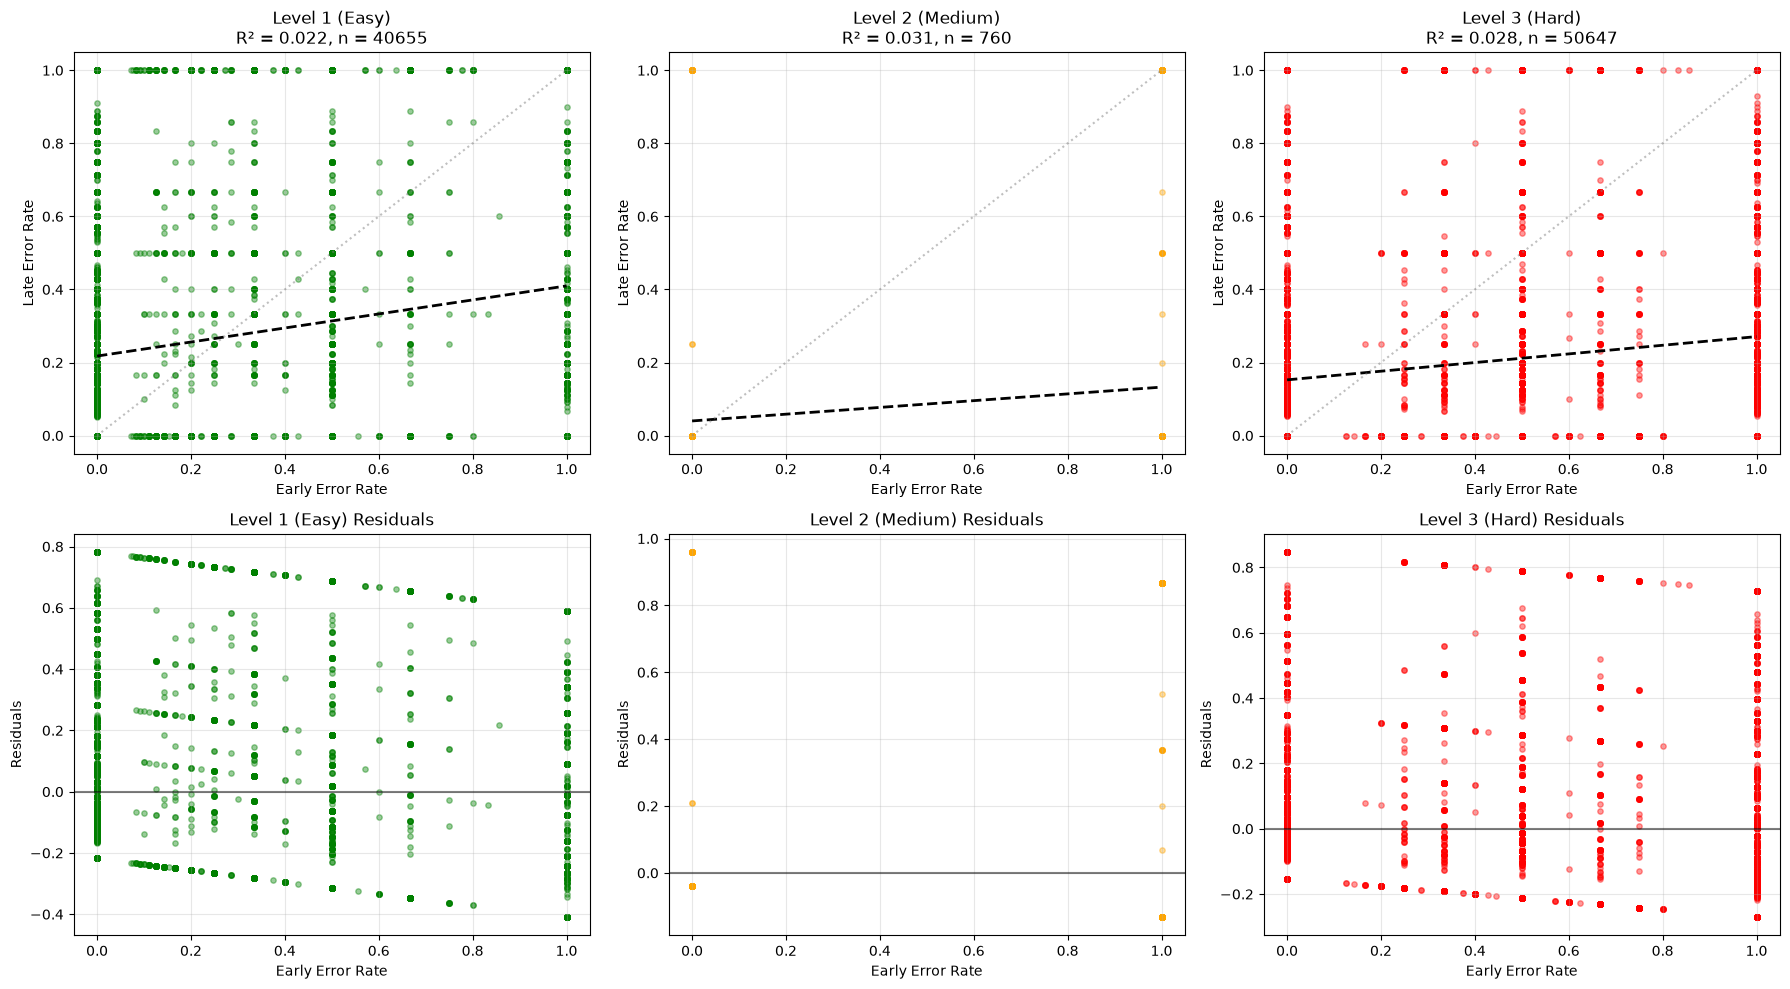


Level 1 - Top Improvers (late error MUCH lower than predicted):
 uid  concepts  error_early  error_late  residual
   4       177          1.0         0.0  -0.40974
  19        18          1.0         0.0  -0.40974
  20        33          1.0         0.0  -0.40974
  29       183          1.0         0.0  -0.40974
  31       177          1.0         0.0  -0.40974
  35       172          1.0         0.0  -0.40974
  49       139          1.0         0.0  -0.40974
  75       177          1.0         0.0  -0.40974
  91       177          1.0         0.0  -0.40974
  91       180          1.0         0.0  -0.40974

Level 1 - Top Decliners (late error MUCH higher than predicted):
 uid  concepts  error_early  error_late  residual
   3        57          0.0         1.0  0.782331
   6       258          0.0         1.0  0.782331
  10       140          0.0         1.0  0.782331
  20        10          0.0         1.0  0.782331
  20        32          0.0         1.0  0.782331
  23        33     

'if results_l1 is not None:\n    results_l1[\'merged_df\'].to_csv(\'level1_early_late_with_residuals.csv\', index=False)\nif results_l2 is not None:\n    results_l2[\'merged_df\'].to_csv(\'level2_early_late_with_residuals.csv\', index=False)\nif results_l3 is not None:\n    results_l3[\'merged_df\'].to_csv(\'level3_early_late_with_residuals.csv\', index=False)\n\n# Save summary\nr2_df.to_csv(\'early_late_regression_summary.csv\', index=False)\nprint("\n✅ Results saved to CSV files")'

In [27]:
def analyze_early_late_relationship(early_df, late_df, level_name):
    """
    Regress late error onto early error for a given level.
    Returns regression results including R² and residuals.
    """
    
    # Merge early and late on uid and concepts
    merged = early_df.merge(
        late_df,
        on=['uid', 'concepts'],
        suffixes=('_early', '_late')
    )
    
    # Filter to students with at least 1 response in both halves
    merged = merged[merged['solved_early'] >= 1]
    merged = merged[merged['solved_late'] >= 1]
    
    if len(merged) < 2:
        print(f"{level_name}: Insufficient data for regression")
        return None
    
    # Prepare X (early error) and y (late error)
    X = merged[['error_early']].values
    y = merged['error_late'].values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict and calculate residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # Calculate R²
    r2 = r2_score(y, y_pred)
    
    # Get coefficients
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Calculate correlation
    corr = np.corrcoef(X.flatten(), y)[0, 1]
    
    # Add residuals to merged dataframe
    merged['y_pred'] = y_pred
    merged['residual'] = residuals
    
    results = {
        'level': level_name,
        'n_observations': len(merged),
        'n_students': merged['uid'].nunique(),
        'n_kcs': merged['concepts'].nunique(),
        'slope': slope,
        'intercept': intercept,
        'correlation': corr,
        'r_squared': r2,
        'rmse': np.sqrt(np.mean(residuals ** 2)),
        'mae': np.mean(np.abs(residuals)),
        'merged_df': merged  # Contains residuals for further analysis
    }
    
    return results

# Run for each level
results_l1 = analyze_early_late_relationship(level_1_early, level_1_late, 'Level 1')
results_l2 = analyze_early_late_relationship(level_2_early, level_2_late, 'Level 2')
results_l3 = analyze_early_late_relationship(level_3_early, level_3_late, 'Level 3')

# ============================================================
# Print summary results
# ============================================================

print("\n" + "="*60)
print("REGRESSION: LATE ERROR ~ EARLY ERROR")
print("="*60)

for results in [results_l1, results_l2, results_l3]:
    if results is None:
        continue
    
    print(f"\n{results['level']}:")
    print(f"  Observations: {results['n_observations']}")
    print(f"  Students: {results['n_students']}")
    print(f"  KCs: {results['n_kcs']}")
    print(f"  R²: {results['r_squared']:.4f}")
    print(f"  Correlation: {results['correlation']:.4f}")
    print(f"  Slope: {results['slope']:.4f}")
    print(f"  Intercept: {results['intercept']:.4f}")
    print(f"  RMSE: {results['rmse']:.4f}")
    print(f"  MAE: {results['mae']:.4f}")

# ============================================================
# Visualize the regression
# ============================================================



fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (results, level_name, color) in enumerate([
    (results_l1, 'Level 1 (Easy)', 'green'),
    (results_l2, 'Level 2 (Medium)', 'orange'),
    (results_l3, 'Level 3 (Hard)', 'red')
]):
    if results is None:
        continue
    
    merged = results['merged_df']
    
    # Scatter plot with regression line
    ax1 = axes[0, idx]
    ax1.scatter(merged['error_early'], merged['error_late'], alpha=0.4, color=color, s=15)
    
    # Regression line
    x_line = np.linspace(merged['error_early'].min(), merged['error_early'].max(), 100)
    y_line = results['slope'] * x_line + results['intercept']
    ax1.plot(x_line, y_line, color='black', linestyle='--', linewidth=2)
    
    # Perfect prediction line (y=x)
    ax1.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
    
    ax1.set_xlabel('Early Error Rate')
    ax1.set_ylabel('Late Error Rate')
    ax1.set_title(f"{level_name}\nR² = {results['r_squared']:.3f}, n = {results['n_observations']}")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.05, 1.05)
    ax1.set_ylim(-0.05, 1.05)
    
    # Residuals plot
    ax2 = axes[1, idx]
    ax2.scatter(merged['error_early'], merged['residual'], alpha=0.4, color=color, s=15)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_xlabel('Early Error Rate')
    ax2.set_ylabel('Residuals')
    ax2.set_title(f'{level_name} Residuals')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('early_late_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Analyze residuals: who improved more than expected?
# ============================================================

def analyze_residuals(results):
    """
    Find students/KCs with large positive/negative residuals.
    Negative residual = late error is lower than predicted (improved more than expected).
    """
    if results is None:
        return
    
    merged = results['merged_df']
    merged['residual_abs'] = np.abs(merged['residual'])
    
    # Top improvers (most negative residuals)
    top_improvers = merged.nsmallest(10, 'residual')
    print(f"\n{results['level']} - Top Improvers (late error MUCH lower than predicted):")
    print(top_improvers[['uid', 'concepts', 'error_early', 'error_late', 'residual']].to_string(index=False))
    
    # Top decliners (most positive residuals)
    top_decliners = merged.nlargest(10, 'residual')
    print(f"\n{results['level']} - Top Decliners (late error MUCH higher than predicted):")
    print(top_decliners[['uid', 'concepts', 'error_early', 'error_late', 'residual']].to_string(index=False))

# Run residual analysis
analyze_residuals(results_l1)
analyze_residuals(results_l2)
analyze_residuals(results_l3)

# ============================================================
# Compare R² across levels
# ============================================================

print("\n" + "="*60)
print("R² COMPARISON ACROSS LEVELS")
print("="*60)

r2_data = []
for results in [results_l1, results_l2, results_l3]:
    if results is not None:
        r2_data.append({
            'level': results['level'],
            'r_squared': results['r_squared'],
            'correlation': results['correlation'],
            'n': results['n_observations']
        })

r2_df = pd.DataFrame(r2_data)
print(r2_df.to_string(index=False))

# ============================================================
# Save results
# ============================================================

# Save merged dataframes with residuals
"""if results_l1 is not None:
    results_l1['merged_df'].to_csv('level1_early_late_with_residuals.csv', index=False)
if results_l2 is not None:
    results_l2['merged_df'].to_csv('level2_early_late_with_residuals.csv', index=False)
if results_l3 is not None:
    results_l3['merged_df'].to_csv('level3_early_late_with_residuals.csv', index=False)

# Save summary
r2_df.to_csv('early_late_regression_summary.csv', index=False)
print("\n✅ Results saved to CSV files")"""